# Apex Project

# **Problem P4** - Retail and E Commerce: Conversational Inventory AI Pipeline

**BITS Pilani BS Program | Apex Project | Trimester 3**

Dataset

**Online Retail II** (2009–2011) - UCI Machine Learning Repository

Source: https://archive.ics.uci.edu/dataset/502/online+retail+ii

Size: ~ 1,067,371 rows across two sheets (2009–2010 and 2010–2011),
8 columns each

# Setup and Imports

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully.')

All libraries loaded successfully.


# Step 1: Load both Excel sheets and merge

In [14]:
#Loading each sheet separately
sheet_2009 = pd.read_excel("/content/online_retail_II.xlsx", sheet_name = "Year 2009-2010")
sheet_2010 = pd.read_excel("/content/online_retail_II.xlsx", sheet_name = "Year 2010-2011")

sheet_2009["source_year"] = "2009-2010"
sheet_2010["source_year"] = "2010-2011"

df_raw = pd.concat([sheet_2009, sheet_2010], ignore_index = True)
df = df_raw.copy()

print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Loaded: 1067371 rows, 9 columns


In [15]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,source_year
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-2010


In [16]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,source_year
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,2010-2011
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,2010-2011
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,2010-2011
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,2010-2011
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France,2010-2011


In [17]:
print("Column Names:", df.columns.tolist())

Column Names: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'source_year']


# Step 2: Data Inspection

In [18]:
print("Data types and non-null counts")
df.info()

Data types and non-null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
 8   source_year  1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 73.3+ MB


In [19]:
print("Statistical Summary")
df.describe()

Statistical Summary


,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


In [20]:
print("Null counts per column")
null_counts = df.isnull().sum()
print(null_counts)

Null counts per column
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
source_year         0
dtype: int64


In [21]:
dup_count = df.duplicated(subset = ["Invoice", "StockCode", "Description", "Quantity", "InvoiceDate", "Price", "Customer ID", "Country"]).sum()
print(f"Duplicate rows: {dup_count}")

Duplicate rows: 34335


In [22]:
df["Country"].value_counts().head(10)

,count
Country,
United Kingdom,981330
EIRE,17866
Germany,17624
France,14330
Netherlands,5140
Spain,3811
Switzerland,3189
Belgium,3123
Portugal,2620


In [23]:
df["Description"].value_counts().head(10)

,count
Description,
WHITE HANGING HEART T-LIGHT HOLDER,5918
REGENCY CAKESTAND 3 TIER,4412
JUMBO BAG RED RETROSPOT,3469
ASSORTED COLOUR BIRD ORNAMENT,2958
PARTY BUNTING,2765
STRAWBERRY CERAMIC TRINKET BOX,2613
LUNCH BAG BLACK SKULL.,2529
JUMBO STORAGE BAG SUKI,2434
HEART OF WICKER SMALL,2319


In [24]:
#Before snapshot

before = {
    "row_count": len(df),
    "null_Description": int(df["Description"].isnull().sum()),
    "null_CustomerID": int(df["Customer ID"].isnull().sum()),
    "duplicate_rows": int(dup_count),
    "negative_quantity_rows": int((df["Quantity"] < 0).sum()),
    "zero_or_negative_price_rows": int((df["Price"] <= 0).sum()),
    "distinct_stockcodes": int(df["StockCode"].astype(str).nunique())
}

print("BEFORE snapshot saved:")
for k, v in before.items():
  print(f" {k}: {v}")

BEFORE snapshot saved:
 row_count: 1067371
 null_Description: 4382
 null_CustomerID: 243007
 duplicate_rows: 34335
 negative_quantity_rows: 22950
 zero_or_negative_price_rows: 6207
 distinct_stockcodes: 5305


# Step 3: Separate returns from sales

In [25]:
returns_df = df[df["Quantity"] < 0].copy()
sales_df = df[df["Quantity"] > 0].copy()

print(f"Number of return rows: {len(returns_df):,}")
print(f"Number of sales rows: {len(sales_df):,}")

print(f"Rows dropped: {(df["Quantity"] == 0).sum():,}")

# print(len(returns_df) + len(sales_df) + int((df["Quantity"] == 0).sum()))


Number of return rows: 22,950
Number of sales rows: 1,044,421
Rows dropped: 0


# Step 4: Remove fully duplicate rows

In [26]:
orig_cols = ["Invoice","StockCode","Description","Quantity","InvoiceDate","Price","Customer ID","Country"]
rows_before_dedup = len(sales_df)
sales_df = sales_df.drop_duplicates(subset=orig_cols).copy()
dupes_removed = rows_before_dedup - len(sales_df)

print(f"Duplicate rows removed: {dupes_removed:,}")
print(f"Number of sales rows after deduplication: {len(sales_df):,}")
print(f"Remaining exact duplicates: {sales_df.duplicated(subset=orig_cols).sum()}")

Duplicate rows removed: 33,881
Number of sales rows after deduplication: 1,010,540
Remaining exact duplicates: 0


# Step 5: Handle missing Customer ID

In [27]:
sales_df["is_guest"] = sales_df["Customer ID"].isnull()

#Flagging null customer id rows as is_guest instead of dropping - To retain the sales volume
n_guest = int(sales_df["is_guest"].sum())
print(f"Rows flagged as is_guest: {n_guest:,} ({n_guest/len(sales_df)*100:.1f}% of sales rows)")


Rows flagged as is_guest: 231,045 (22.9% of sales rows)


# Step 6: Fix price anomalies

In [28]:
invalid_price_mask = sales_df["Price"] <= 0
n_invalid_price = int(invalid_price_mask.sum())
sales_df.loc[invalid_price_mask, "Price"] = np.nan

# Zero / negative prices to NaN - not possible values
median_price_per_sku = sales_df.groupby("StockCode")["Price"].transform("median")
sales_df["Price"] = sales_df["Price"].fillna(median_price_per_sku)

# Filled missing prices using each product's own median - to maintain realistic prices
n_fallback = int(sales_df["Price"].isnull().sum())
overall_median = sales_df["Price"].median()
sales_df["Price"] = sales_df["Price"].fillna(overall_median)

# Some SKUs had zero valid prices to average
print(f"Number of rows with invalid price : {n_invalid_price:,}")
print(f"Rows with invalid price fixed using product median: {n_fallback:,}")
print(f"Rows with invalid price fixed overall median: {overall_median:.2f}")
print(f"Non-positive prices remaining : {(sales_df['Price'] <= 0).sum()}")
print(f"Null prices remaining : {sales_df['Price'].isnull().sum()}")

Number of rows with invalid price : 2,626
Rows with invalid price fixed using product median: 70
Rows with invalid price fixed overall median: 2.10
Non-positive prices remaining : 0
Null prices remaining : 0


# Step 7: Standardise InvoiceDate

In [29]:
#Converted InvoiceDate to real datetime
sales_df["InvoiceDate"] = pd.to_datetime(sales_df["InvoiceDate"])

#Pulled out date, month and year separately - convenient for us to group it later
sales_df["invoice_date"]  = sales_df["InvoiceDate"].dt.date
sales_df["invoice_month"] = sales_df["InvoiceDate"].dt.month
sales_df["invoice_year"]  = sales_df["InvoiceDate"].dt.year

print("InvoiceDate dtype:", sales_df["InvoiceDate"].dtype)
print("Date range:", sales_df["InvoiceDate"].min(), "to", sales_df["InvoiceDate"].max())
print("Years covered in this data:", sorted(sales_df["invoice_year"].unique()))

InvoiceDate dtype: datetime64[ns]
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Years covered in this data: [np.int32(2009), np.int32(2010), np.int32(2011)]


# Step 8: Standardise StockCode and Description

In [30]:
sales_df["StockCode"] = sales_df["StockCode"].astype(str).str.strip()

n_post_strip_dupes = int(sales_df.duplicated(subset=orig_cols).sum())
sales_df = sales_df.drop_duplicates(subset=orig_cols).copy()
# Trimming StockCode spaces made 6 more rows identical - dropped those too

desc_clean = sales_df["Description"].astype("string").str.strip().str.title()
# Cleaned up Description casing/spacing but kept the original column untouched

canonical_map = (
    desc_clean.dropna()
    .groupby(sales_df["StockCode"])
    .agg(lambda s: s.value_counts().idxmax())
)
# Picked the most common name per product - some items had 5+ different labels

n_multi_desc_before = int((desc_clean.groupby(sales_df["StockCode"]).nunique() > 1).sum())

sales_df["canonical_description"] = sales_df["StockCode"].map(canonical_map)
n_no_desc = int(sales_df["canonical_description"].isnull().sum())
sales_df["canonical_description"] = sales_df["canonical_description"].fillna("Unknown Product")
# 753 products had no description at all anywhere - labeled these "Unknown Product"

desc_variety = desc_clean.groupby(sales_df["StockCode"]).nunique()
flagged_skus = desc_variety[desc_variety > 5]
# Flagged products with more than 5 different names - worth a manual look later

print("New duplicates found after trimming StockCode:", n_post_strip_dupes)
print("Products that had multiple different names:", f"{n_multi_desc_before:,}")
print("Rows with no name at all to labeled Unknown:", f"{n_no_desc:,}")
print("Products flagged for manual review:", len(flagged_skus))
print(flagged_skus.sort_values(ascending=False).head(10))
print("Products still missing a final name:", sales_df["canonical_description"].isnull().sum())

New duplicates found after trimming StockCode: 6
Products that had multiple different names: 753
Rows with no name at all to labeled Unknown: 66
Products flagged for manual review: 2
StockCode
22734    6
23084    6
Name: Description, dtype: int64
Products still missing a final name: 0


# Step 9: Standardise Country labels

In [31]:
sales_df["Country"] = sales_df["Country"].astype(str).str.strip().str.title()
# Standardized casing/spacing so "uk", "UK", "Uk " all match

country_variant_map = {
    "Eire": "Ireland",
    "Rsa": "South Africa",
    "Usa": "USA",
    "Uk": "United Kingdom",
    "U.K.": "United Kingdom",
    "European Community": "European Community",
    "Unspecified": "Unknown",
}
sales_df["Country"] = sales_df["Country"].replace(country_variant_map)
# Merged old/alternate country names (Eire, Rsa, Uk) into their modern equivalents
# Renamed "Unspecified" to "Unknown" - clearer that the country just wasn't recorded

print("Countries left after cleanup :", sales_df["Country"].nunique())
print(sales_df["Country"].value_counts().head(12))

Countries left after cleanup : 43
Country
United Kingdom     928634
Ireland             17159
Germany             16439
France              13640
Netherlands          5090
Spain                3663
Switzerland          3123
Belgium              3056
Portugal             2470
Australia            1792
Channel Islands      1551
Italy                1442
Name: count, dtype: int64


# Step 10: Encode categorical columns

In [32]:
le_country = LabelEncoder()
sales_df["country_encoded"] = le_country.fit_transform(sales_df["Country"])
# Turned Country into numbers so models can use it - kept the original column too

sales_df["is_guest"] = sales_df["is_guest"].astype(int)
# Switched is_guest from True/False to 1/0 - easier to feed into most models

print("Total country codes assigned:", sales_df["country_encoded"].nunique())
print("First 5 country → code pairs:", dict(list(zip(le_country.classes_[:5], range(5)))))
print(sales_df[["Country", "country_encoded", "is_guest", "invoice_month"]].head())

Total country codes assigned: 43
First 5 country → code pairs: {'Australia': 0, 'Austria': 1, 'Bahrain': 2, 'Belgium': 3, 'Bermuda': 4}
          Country  country_encoded  is_guest  invoice_month
0  United Kingdom               40         0             12
1  United Kingdom               40         0             12
2  United Kingdom               40         0             12
3  United Kingdom               40         0             12
4  United Kingdom               40         0             12


# Step 11: Aggregate by product and month

In [33]:
sales_df["line_total"] = sales_df["Quantity"] * sales_df["Price"]
# Added line_total (qty x price) so revenue is easy to sum per row

retail_monthly = (
    sales_df.groupby(["StockCode", "canonical_description", "invoice_year", "invoice_month"], as_index=False)
    .agg(total_units_sold=("Quantity", "sum"),
         total_revenue=("line_total", "sum"),
         num_invoices=("Invoice", "nunique"))
)
# Aggregated to one row per product per month
print("Product-month table size    :", retail_monthly.shape)
print(retail_monthly.head())

Product-month table size    : (67390, 7)
  StockCode       canonical_description  invoice_year  invoice_month  \
0     10002  Inflatable Political Globe          2009             12   
1     10002  Inflatable Political Globe          2010              1   
2     10002  Inflatable Political Globe          2010              2   
3     10002  Inflatable Political Globe          2010              3   
4     10002  Inflatable Political Globe          2010              4   

   total_units_sold  total_revenue  num_invoices  
0               215         185.30            20  
1               291         248.97            17  
2               257         220.07            15  
3               641         493.09            17  
4              1132         843.73            24  


# Step 12: Normalise numeric columns

In [34]:
scaler = MinMaxScaler()
retail_monthly[["total_units_sold_scaled", "total_revenue_scaled"]] = scaler.fit_transform(
    retail_monthly[["total_units_sold", "total_revenue"]]
)
# Added 0-1 scaled versions of units and revenue so products can be compared fairly - kept the raw numbers too

print(retail_monthly[["total_units_sold", "total_units_sold_scaled", "total_revenue", "total_revenue_scaled"]].describe())

       total_units_sold  total_units_sold_scaled  total_revenue  \
count      67390.000000             67390.000000   67390.000000   
mean         169.993738                 0.002086     317.144153   
std          622.584742                 0.007687    1419.805663   
min            1.000000                 0.000000       0.001000   
25%            7.000000                 0.000074      18.900000   
50%           36.000000                 0.000432      71.095000   
75%          147.000000                 0.001803     259.007500   
max        80995.000000                 1.000000  168469.600000   

       total_revenue_scaled  
count          67390.000000  
mean               0.001882  
std                0.008428  
min                0.000000  
25%                0.000112  
50%                0.000422  
75%                0.001537  
max                1.000000  


# Step 13: Generate before/after quality report

In [35]:
after = {
    "row_count": len(sales_df),
    "null_Description": int(sales_df["canonical_description"].isnull().sum()),
    "null_CustomerID": int(sales_df["Customer ID"].isnull().sum()),  # kept on purpose, tagged via is_guest
    "duplicate_rows": int(sales_df.duplicated(subset=orig_cols).sum()),
    "negative_quantity_rows": int((sales_df["Quantity"] < 0).sum()),
    "zero_or_negative_price_rows": int((sales_df["Price"] <= 0).sum()),
    "distinct_stockcodes": int(sales_df["StockCode"].nunique()),
}

print("AFTER SNAPSHOT")
for k, v in after.items():
    print(f"  {k:30s}: {v:,}")

quality_report = pd.DataFrame({
    "metric": list(before.keys()),
    "before_cleaning": [before[k] for k in before],
    "after_cleaning": [after[k] for k in before],
})
quality_report["change"] = quality_report["after_cleaning"] - quality_report["before_cleaning"]
quality_report.to_csv("quality_report.csv", index=False)
print("\nSaved before/after comparison to quality_report.csv")
print(quality_report.to_string(index=False))
print("\nMissing Customer IDs were kept on purpose and flagged with is_guest (Step 5).")
print(f"Returns kept separately in returns_df: {len(returns_df):,} rows (moved out, not deleted).")

AFTER SNAPSHOT
  row_count                     : 1,010,534
  null_Description              : 0
  null_CustomerID               : 231,043
  duplicate_rows                : 0
  negative_quantity_rows        : 0
  zero_or_negative_price_rows   : 0
  distinct_stockcodes           : 4,984

Saved before/after comparison to quality_report.csv
                     metric  before_cleaning  after_cleaning  change
                  row_count          1067371         1010534  -56837
           null_Description             4382               0   -4382
            null_CustomerID           243007          231043  -11964
             duplicate_rows            34335               0  -34335
     negative_quantity_rows            22950               0  -22950
zero_or_negative_price_rows             6207               0   -6207
        distinct_stockcodes             5305            4984    -321

Missing Customer IDs were kept on purpose and flagged with is_guest (Step 5).
Returns kept separately in retu

# Step 14: Export clean dataset

In [36]:
clean_tx_cols = ["Invoice", "StockCode", "canonical_description", "Quantity", "Price", "line_total",
                  "InvoiceDate", "invoice_date", "invoice_month", "invoice_year", "source_year",
                  "Customer ID", "is_guest", "Country", "country_encoded"]
clean_transactions = sales_df[clean_tx_cols].copy()
clean_transactions.to_csv("clean_transactions.csv", index=False)
# Saved the full row-level cleaned data - one file, every transaction

retail_monthly.to_csv("clean_retail.csv", index=False)
# Saved the product-month rollup separately - this is the smaller file an app would actually query

key_cols = ["StockCode", "canonical_description", "Quantity", "Price", "InvoiceDate"]
print(f"clean_transactions.csv : {clean_transactions.shape[0]:,} rows x {clean_transactions.shape[1]} columns")
print(f"  Missing values in core columns: {int(clean_transactions[key_cols].isnull().sum().sum())}")
print(f"clean_retail.csv       : {retail_monthly.shape[0]:,} rows x {retail_monthly.shape[1]} columns")
print(f"  Missing values anywhere       : {int(retail_monthly.isnull().sum().sum())}")

clean_transactions.csv : 1,010,534 rows x 15 columns
  Missing values in core columns: 0
clean_retail.csv       : 67,390 rows x 9 columns
  Missing values anywhere       : 0


# Analysis 1: Top 20 products by total units sold

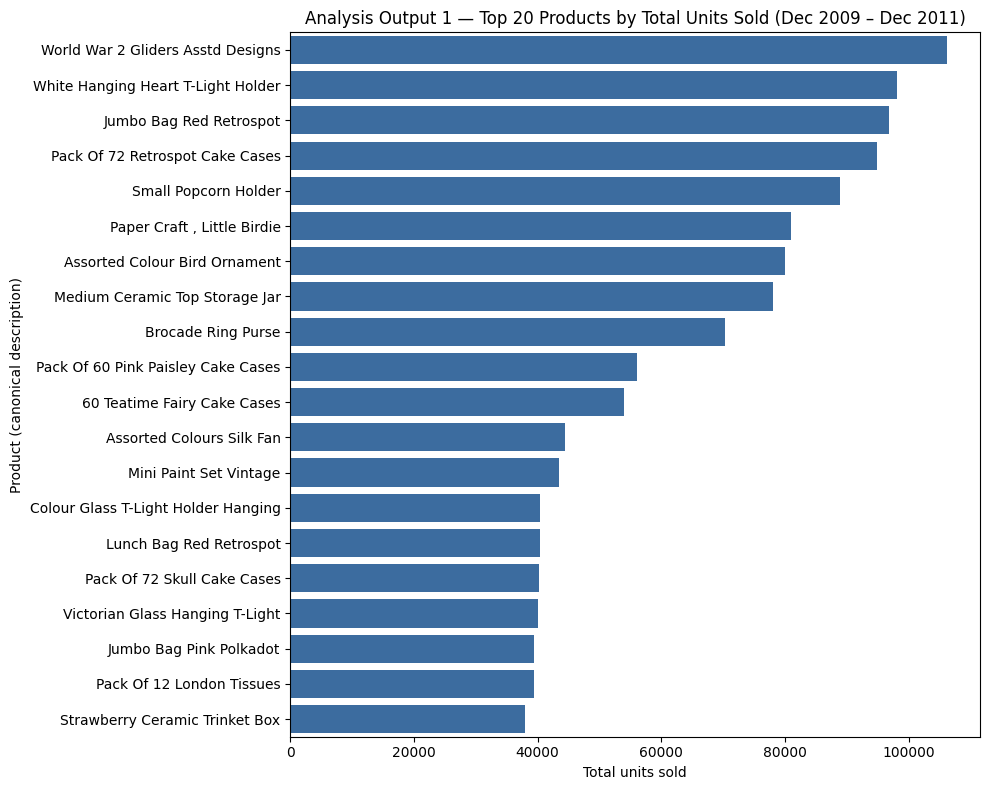

StockCode               canonical_description  total_units_sold
    84077   World War 2 Gliders Asstd Designs            106250
   85123A  White Hanging Heart T-Light Holder             98208
   85099B             Jumbo Bag Red Retrospot             96764
    21212     Pack Of 72 Retrospot Cake Cases             94884
    22197                Small Popcorn Holder             88993
    23843         Paper Craft , Little Birdie             80995
    84879       Assorted Colour Bird Ornament             80090
    23166      Medium Ceramic Top Storage Jar             78033
    17003                  Brocade Ring Purse             70379
    21977  Pack Of 60 Pink Paisley Cake Cases             56061
    84991         60 Teatime Fairy Cake Cases             54028
    15036           Assorted Colours Silk Fan             44392
    22492              Mini Paint Set Vintage             43546
    84755 Colour Glass T-Light Holder Hanging             40439
    20725             Lunch Bag Red Retr

In [39]:
top20 = (retail_monthly.groupby(["StockCode","canonical_description"], as_index=False)["total_units_sold"]
                        .sum().sort_values("total_units_sold", ascending=False).head(20))

plt.figure(figsize=(10, 8))
sns.barplot(data=top20, y="canonical_description", x="total_units_sold", color="#2b6cb0")
plt.title("Analysis Output 1 — Top 20 Products by Total Units Sold (Dec 2009 – Dec 2011)")
plt.xlabel("Total units sold")
plt.ylabel("Product (canonical description)")
plt.tight_layout()
plt.savefig("analysis_output_1_top20_products.png", dpi=150)
plt.show()

print(top20.to_string(index=False))

# Analyis 2: Products with zero sales month

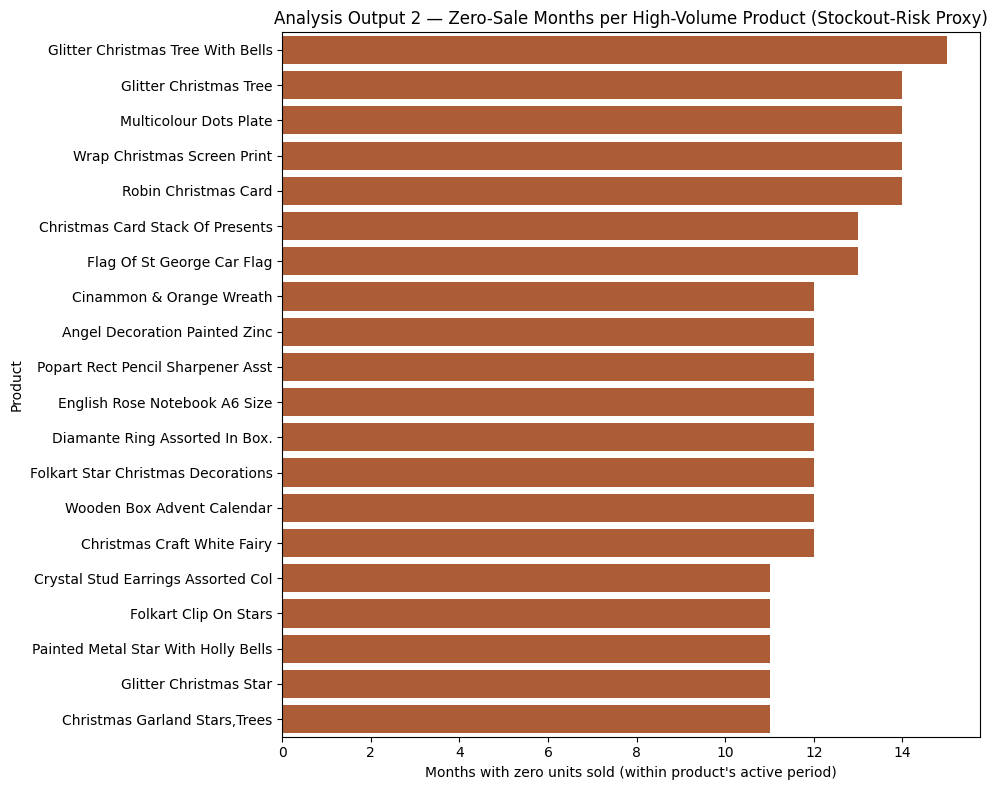

Products with at least one zero-sale month inside their active period: 2,280 of 4,984
StockCode               canonical_description  zero_sale_months  total_units
    21822   Glitter Christmas Tree With Bells                15         1010
    21817              Glitter Christmas Tree                14         1687
    37471              Multicolour Dots Plate                14         1405
    22049         Wrap Christmas Screen Print                14         3500
    22034                Robin Christmas Card                14         1629
    22044    Christmas Card Stack Of Presents                13         1940
    84016          Flag Of St George Car Flag                13        19000
    21351            Cinammon & Orange Wreath                12         1099
    22337       Angel Decoration Painted Zinc                12         2473
    16054   Popart Rect Pencil Sharpener Asst                12         1210
   84535A       English Rose Notebook A6 Size                12    

In [40]:
rm = retail_monthly.copy()
rm["ym"] = pd.to_datetime(dict(year=rm["invoice_year"], month=rm["invoice_month"], day=1)).dt.to_period("M")

def zero_months(g):
    full = pd.period_range(g["ym"].min(), g["ym"].max(), freq="M")
    return len(full) - g["ym"].nunique()

gap_counts = rm.groupby(["StockCode","canonical_description"]).apply(zero_months, include_groups=False).rename("zero_sale_months").reset_index()
volume = rm.groupby("StockCode")["total_units_sold"].sum().rename("total_units").reset_index()
gap_counts = gap_counts.merge(volume, on="StockCode")

risky = gap_counts[gap_counts["total_units"] >= 1000].sort_values("zero_sale_months", ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=risky, y="canonical_description", x="zero_sale_months", color="#c05621")
plt.title("Analysis Output 2 — Zero-Sale Months per High-Volume Product (Stockout-Risk Proxy)")
plt.xlabel("Months with zero units sold (within product's active period)")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("analysis_output_2_stockout_proxy.png", dpi=150)
plt.show()

n_any_gap = int((gap_counts["zero_sale_months"] > 0).sum())
print(f"Products with at least one zero-sale month inside their active period: {n_any_gap:,} of {len(gap_counts):,}")
print(risky.to_string(index=False))

# Analysis 3: Monthly revenue trend

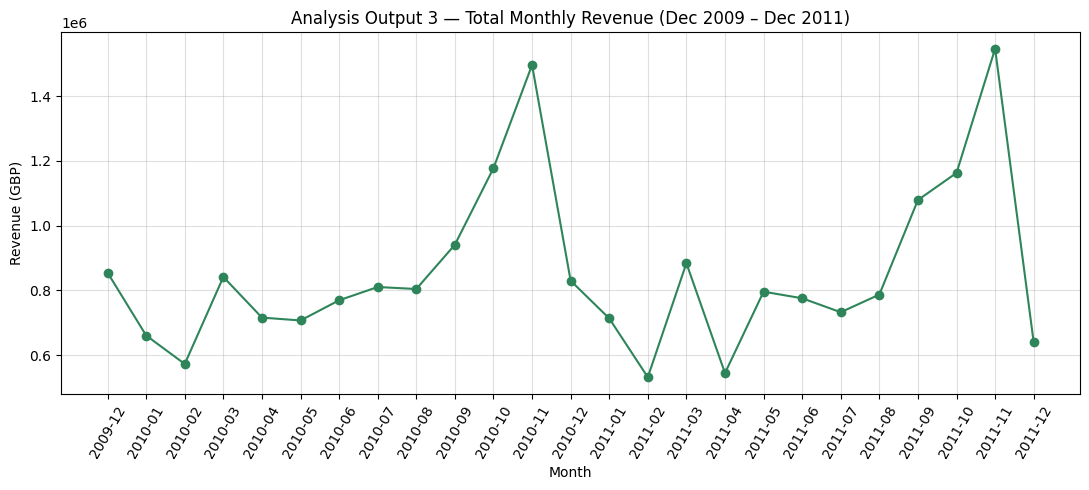

Peak revenue month: 2011-11 = 1,545,856
ym
2009-12     854656.0
2010-01     660674.0
2010-02     572798.0
2010-03     841397.0
2010-04     715988.0
2010-05     707067.0
2010-06     769450.0
2010-07     810368.0
2010-08     804215.0
2010-09     940887.0
2010-10    1177251.0
2010-11    1495662.0
2010-12     829828.0
2011-01     713482.0
2011-02     532034.0
2011-03     883827.0
2011-04     544763.0
2011-05     795989.0
2011-06     775589.0
2011-07     732535.0
2011-08     786986.0
2011-09    1078935.0
2011-10    1162582.0
2011-11    1545856.0
2011-12     639525.0
Freq: M


In [41]:
monthly_rev = rm.groupby("ym")["total_revenue"].sum().sort_index()

plt.figure(figsize=(11, 5))
plt.plot(monthly_rev.index.astype(str), monthly_rev.values, marker="o", color="#2f855a")
plt.title("Analysis Output 3 — Total Monthly Revenue (Dec 2009 – Dec 2011)")
plt.xlabel("Month")
plt.ylabel("Revenue (GBP)")
plt.xticks(rotation=60)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("analysis_output_3_monthly_revenue.png", dpi=150)
plt.show()

peak = monthly_rev.idxmax()
print(f"Peak revenue month: {peak} = {monthly_rev.max():,.0f}")
print(monthly_rev.round(0).to_string())

# Analysis 4: Top 10 countries by revenue and units sold

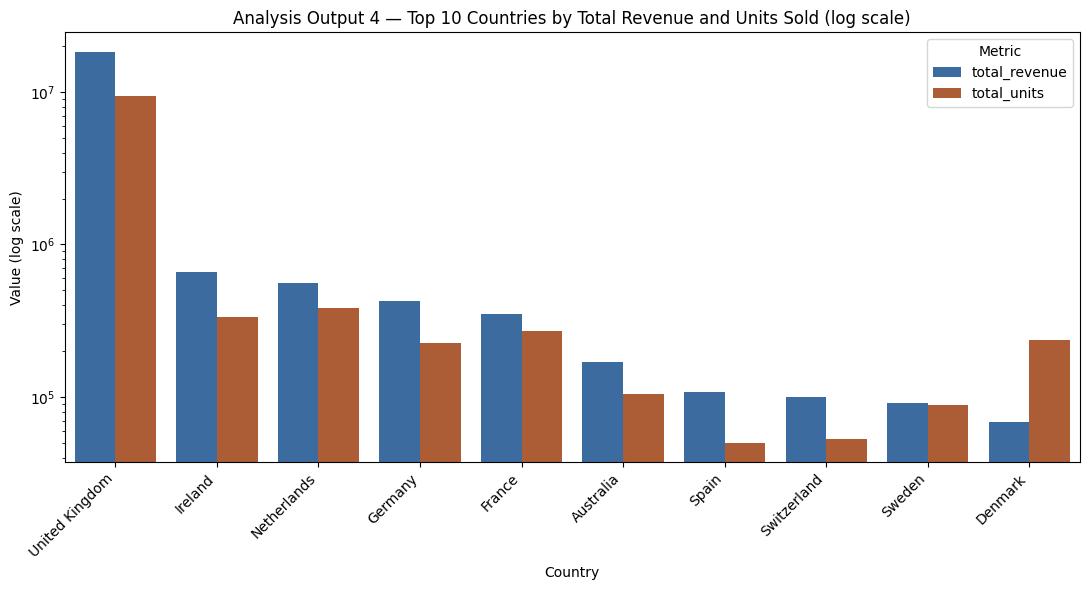

       Country  total_revenue  total_units
United Kingdom   18303458.968      9437218
       Ireland     659518.360       336604
   Netherlands     554996.650       384519
       Germany     425114.011       225172
        France     350459.040       271902
     Australia     170231.100       104067
         Spain     108379.240        50318
   Switzerland     100694.090        52763
        Sweden      91869.820        88633
       Denmark      68580.690       237471


In [42]:
country_summary = (sales_df.groupby("Country")
                            .agg(total_revenue=("line_total","sum"), total_units=("Quantity","sum"))
                            .sort_values("total_revenue", ascending=False).head(10).reset_index())

melted = country_summary.melt(id_vars="Country", var_name="Metric", value_name="Value")
plt.figure(figsize=(11, 6))
sns.barplot(data=melted, x="Country", y="Value", hue="Metric", palette=["#2b6cb0","#c05621"])
plt.yscale("log")
plt.title("Analysis Output 4 — Top 10 Countries by Total Revenue and Units Sold (log scale)")
plt.xlabel("Country")
plt.ylabel("Value (log scale)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("analysis_output_4_top_countries.png", dpi=150)
plt.show()

print(country_summary.to_string(index=False))